# Week 4 Day 2 Lab


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Problem 1: Random Data Set
1. Generate a data set of size 300 using `np.random` 
2. Save this data set as a pandas dataframe
3. Download the dataset as a csv using `dataframe_name.to_csv("file_name.csv", index=False)`

In [2]:
np.random.seed(42) 

random_data = np.random.randint(1, 21, size=300)
random_dataframe = pd.DataFrame({
    'value': random_data
})

random_dataframe.to_csv('random_data.csv', index=False) 

### Problem 2: Measures of Centrality
There are many ways to calculate what a data set is centered around. A few examples you have seen:

- Mean - The average of a dataset ($\bar{x}=\frac{1}{n}\sum\limits_{i=1}^nx_i$ for data points $x_i$)
- Median - The "middle data point" (average of 2 middle data points if data size is even-sized)
- Mode - The most common value (value with most number of occurences in data set)


1. Write your own function that calculate each of these.
2. Read the csv from Problem 1 into your notebook using `pd.read_csv("file_name.csv")`
3. Plot a histogram of the data and use `plt.axvline()` to plot vertical lines for the mean, median, and mode on the same histogram. 
4. Do you notice anything about the mean, median, and mode? How can you explain this behavior?

Mean: 9.93
Median: 9.0
Mode or modes: [3, 1]


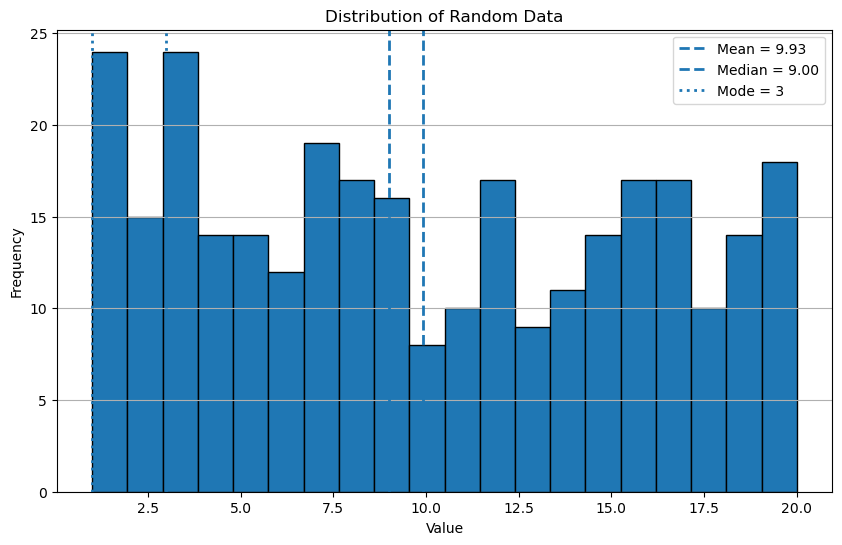

In [ ]:
#1
def my_mean(data):
    total = 0

    for value in data:
        total += value

    return total / len(data)

def my_median(data):
    sorted_data = sorted(data)
    n = len(sorted_data)
    middle = n // 2

    if n % 2 == 1:
        return sorted_data[middle]
    else:
        return (sorted_data[middle - 1] + sorted_data[middle]) / 2

def my_mode(data):
    counts = {}

    for value in data:
        if value in counts:
            counts[value] += 1
        else:
            counts[value] = 1

    highest_count = max(counts.values())
    modes = []

    for value, count in counts.items():
        if count == highest_count:
            modes.append(value)

    return modes

#2
dataframe = pd.read_csv("/Users/lukelewis/Downloads/random_data.csv")

data = dataframe["value"].tolist()

mean_value = my_mean(data)
median_value = my_median(data)
mode_values = my_mode(data)

print("Mean:", mean_value)
print("Median:", median_value)
print("Mode or modes:", mode_values)

#3
plt.figure(figsize=(10, 6))

plt.hist(
    data,
    bins=20,
    edgecolor="black"
)

plt.axvline(
    mean_value,
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_value:.2f}"
)

plt.axvline(
    median_value,
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_value:.2f}"
)

for index, mode_value in enumerate(mode_values):
    if index == 0:
        plt.axvline(
            mode_value,
            linestyle=":",
            linewidth=2,
            label=f"Mode = {mode_value}"
        )
    else:
        plt.axvline(
            mode_value,
            linestyle=":",
            linewidth=2
        )

plt.title("Distribution of Random Data")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis="y")
plt.show()

In [ ]:
#4
#The mean and median should be near the center of the range because the values were generated from a roughly uniform distribution.
#The mode can move around more because it represents the value that occured more frequently in the random data sample.

### Problem 3: Measures of Variability
We don't care solely where the data is centered, but also how spread out the data is around that center. Some ways we can measure this:
- Mean Absolute Deviation - Average of distance to the mean ($MAD(x)= \frac{1}{n}\sum\limits_{i=1}^n|x_i-\bar{x}|$)
- Variance - Average squared distance to the mean ($Var(x)=\frac{1}{n}\sum\limits_{i=1}^n(x_i-\bar{x})^2$)
- Standard Deviation - Square root of average squared distance to the mean ($s(x)=\sqrt{\frac{1}{n}\sum\limits_{i=1}^n(x_i-\bar{x})^2}$)

where $x$ is the entire dataset, $x_i$ is a data point, and $\bar{x}$ is the mean of the dataset.

1. Write your own function that calculate each of these.
2. Plot a histogram of the data and use `plt.axvline(mean + variance)` and `plt.axvline(mean-variance)` to plot vertical lines for variance on the same histogram. Do the same with adding and subtracting mean absolute deviation and standard deviation.
3. Do you notice anything about lines corresponding to the different definitions variability? How can you explain this behavior?

Mean: 9.93
Mean absolute deviation: 5.347666666666668
Variance: 36.9451
Standard deviation: 6.078248102866483


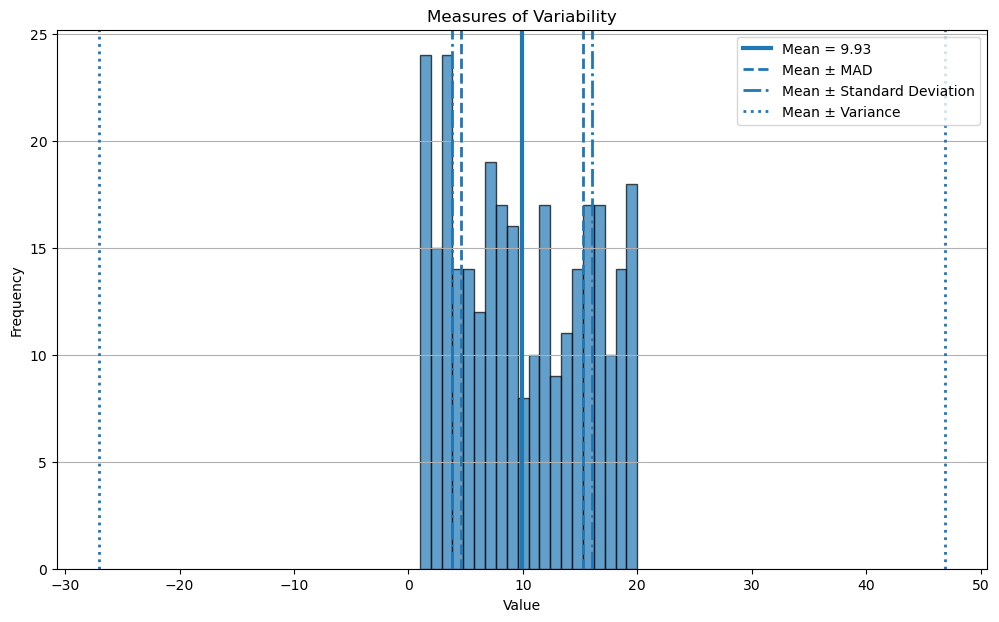

In [5]:
#1
def my_mean_absolute_deviation(data):
    mean_value = my_mean(data)
    total_distance = 0

    for value in data:
        total_distance += abs(value - mean_value)

    return total_distance / len(data)

def my_variance(data):
    mean_value = my_mean(data)
    total_squared_distance = 0

    for value in data:
        total_squared_distance += (value - mean_value) ** 2

    return total_squared_distance / len(data)

def my_standard_deviation(data):
    variance_value = my_variance(data)
    return variance_value ** 0.5

#2
mean_value = my_mean(data)
mad_value = my_mean_absolute_deviation(data)
variance_value = my_variance(data)
standard_deviation_value = my_standard_deviation(data)

print("Mean:", mean_value)
print("Mean absolute deviation:", mad_value)
print("Variance:", variance_value)
print("Standard deviation:", standard_deviation_value)

plt.figure(figsize=(12, 7))

plt.hist(
    data,
    bins=20,
    edgecolor="black",
    alpha=0.7
)

plt.axvline(
    mean_value,
    linewidth=3,
    label=f"Mean = {mean_value:.2f}"
)

plt.axvline(
    mean_value - mad_value,
    linestyle="--",
    linewidth=2,
    label="Mean ± MAD"
)

plt.axvline(
    mean_value + mad_value,
    linestyle="--",
    linewidth=2
)

plt.axvline(
    mean_value - standard_deviation_value,
    linestyle="-.",
    linewidth=2,
    label="Mean ± Standard Deviation"
)

plt.axvline(
    mean_value + standard_deviation_value,
    linestyle="-.",
    linewidth=2
)

plt.axvline(
    mean_value - variance_value,
    linestyle=":",
    linewidth=2,
    label="Mean ± Variance"
)

plt.axvline(
    mean_value + variance_value,
    linestyle=":",
    linewidth=2
)

plt.title("Measures of Variability")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis="y")
plt.show()


In [ ]:
#3
#The mean absolute deviation and the standard deviation lines are relatively close because both measure distance from the mean
#The variance lines are much farther apart because variance uses squared units.
#Variance isn't measured in the same units as the original data, so adding it to the mean creates unusual line distances.